# Pipeline MCTNet — California + Arkansas (Table 2)
## ÉTAPE 1 : Alignement CDL → ÉTAPE 2 : Cube spectral 10 bandes → ÉTAPE 3 : MCT-Net
## Deux études de zone séparées dans le même notebook

> **Structure attendue :**
> ```
> data/
>   raw/
>     californiaX.SAFE
>     arkansasX.SAFE
>   processed/
>     cdl_california_2021.tif
>     cdl_arkansas_2021.tif
> models/
> ```


## 📦 Imports

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
import math
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'

print(f'PyTorch  : {torch.__version__}')
print(f'Rasterio : {rasterio.__version__}')
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
print(f'GPU dispo: {"ok " + gpu if gpu else "CPU uniquement"}')
print('Imports OK')


PyTorch  : 2.11.0+cpu
Rasterio : 1.4.4
GPU dispo: CPU uniquement
Imports OK


## ⚙️ Configuration — Auto-discovery des nouvelles images

> **✅ Après avoir téléchargé de nouvelles images avec `download_sentinel2.py` :**
> Il suffit de **relancer cette cellule** — les nouveaux `.SAFE` sont détectés automatiquement dans `data/raw/` et ajoutés aux `DATES_MAP`.
> Aucune modification manuelle du code n'est nécessaire.

> **Structure des fichiers attendue :**
> ```
> data/raw/
>   S2A_MSIL2A_20210315T184921_..._T10SGH_....SAFE/   ← nouveau téléchargé
>   california1.SAFE/   ← existant
>   arkansas1.SAFE/     ← existant
>   ...
> ```

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION GLOBALE
# ══════════════════════════════════════════════════════════════════════════════

DATA_DIR      = Path('data')
SAFE_DIR      = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('models')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparamètres communs ───────────────────────────────────────────────────
N_BANDS           = 10
BANDS_10M         = ['B02', 'B03', 'B04', 'B08']
BANDS_20M         = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
ALL_BANDS         = BANDS_10M + BANDS_20M
TOTAL_SAMPLES     = 10_000
N_TRAIN_PER_CLASS = 240
N_VAL_PER_CLASS   = 60
BATCH_SIZE        = 32
LR                = 0.0005
EPOCHS            = 200
RANDOM_STATE      = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ══════════════════════════════════════════════════════════════════════════════
# 🔍 AUTO-DISCOVERY — Scan automatique des nouveaux .SAFE téléchargés
# ══════════════════════════════════════════════════════════════════════════════

import re
from datetime import date as _date

def _parse_safe(safe_path):
    """
    Extrait (tile, date_str, granule_dir, file_prefix, doy) depuis un .SAFE.
    Retourne None si le format n'est pas reconnu.
    """
    name = safe_path.name  # ex: S2A_MSIL2A_20210315T184921_N0300_R070_T10SGH_20210315T221038.SAFE
    m = re.search(r'_(\d{8})T\d+_N\d+_R\d+_(T\d+[A-Z]+)_', name)
    if not m:
        return None
    date_str = m.group(1)   # '20210315'
    tile     = m.group(2)   # 'T10SGH'
    try:
        d   = _date(int(date_str[:4]), int(date_str[4:6]), int(date_str[6:8]))
        doy = d.timetuple().tm_yday
    except Exception:
        return None

    # Trouver le dossier GRANULE
    granule_dirs = list((safe_path / 'GRANULE').glob('L2A_*')) if (safe_path / 'GRANULE').exists() else []
    if not granule_dirs:
        return None
    granule_dir = granule_dirs[0].name  # ex: L2A_T10SGH_A022833_20210720T185324

    # Trouver le préfixe des bandes (depuis les jp2 dans R10m)
    r10m = safe_path / 'GRANULE' / granule_dir / 'IMG_DATA' / 'R10m'
    jp2s = list(r10m.glob('*_B04_10m.jp2')) if r10m.exists() else []
    if not jp2s:
        return None
    file_prefix = '_'.join(jp2s[0].name.split('_')[:2])  # ex: T10SGH_20210720T183919

    return {'tile': tile, 'date_str': date_str, 'doy': doy,
            'safe_name': safe_path.name, 'granule_dir': granule_dir,
            'file_prefix': file_prefix}


def build_dates_map(safe_dir, tile_to_zone, base_entries, n_total=36, label=''):
    """
    Construit un DATES_MAP dynamique :
    1. Part des entrées de base (acquisitions connues)
    2. Scanne safe_dir pour les nouveaux .SAFE correspondant aux tuiles attendues
    3. Complète avec des placeholders jusqu'à n_total entrées
    4. Trie par DOY pour que l'interpolation soit correcte

    tile_to_zone : dict  ex: {'T10SGH': 'SGH', 'T10SFG': 'SFG', ...}
    base_entries : dict  entrées déjà connues {nom: (safe, granule, prefix, zone)}
    """
    # Construire un index des dates déjà présentes (évite les doublons)
    known_keys = set()
    for safe, granule, prefix, zone in base_entries.values():
        if safe != '__pad__.SAFE':
            known_keys.add(prefix[:19])  # ex: 'T10SGH_20210720T183'

    # Parcourir les .SAFE dans safe_dir
    new_entries = {}
    for safe_path in sorted(Path(safe_dir).glob('*.SAFE')):
        info = _parse_safe(safe_path)
        if info is None:
            continue
        tile = info['tile']
        if tile not in tile_to_zone:
            continue
        key = info['file_prefix'][:19]
        if key in known_keys:
            continue  # déjà dans base_entries

        zone     = tile_to_zone[tile]
        date_str = info['date_str']
        name_key = f"new_{tile.lower()}_{date_str}"
        new_entries[name_key] = (
            safe_path.name,
            info['granule_dir'],
            info['file_prefix'],
            zone,
        )
        known_keys.add(key)

    # Fusionner base + nouveaux
    all_real = {**base_entries, **new_entries}

    # Retirer les placeholders existants dans base_entries
    all_real = {k: v for k, v in all_real.items() if v[0] != '__pad__.SAFE'}

    n_real = len(all_real)
    n_pad  = max(0, n_total - n_real)

    if new_entries:
        print(f'  [{label}] +{len(new_entries)} nouveaux .SAFE détectés : {list(new_entries.keys())}')

    # Trier par DOY (extrait depuis file_prefix)
    def _doy_from_entry(entry):
        prefix = entry[2]  # file_prefix
        try:
            ds = prefix.split('_')[1][:8]
            d  = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
            return d.timetuple().tm_yday
        except Exception:
            return 999

    sorted_real = dict(sorted(all_real.items(), key=lambda x: _doy_from_entry(x[1])))

    # Ajouter les placeholders
    dates_map = dict(sorted_real)
    for i in range(n_pad):
        dates_map[f'pad_{label.lower()}_{n_real+i+1:02d}'] = ('__pad__.SAFE', '__pad__', '__pad__', list(tile_to_zone.values())[0])

    assert len(dates_map) == n_total, f'DATES_MAP {label} : attendu {n_total}, got {len(dates_map)}'
    return dates_map, n_real, n_pad


# ══════════════════════════════════════════════════════════════════════════════
# 🌴 ZONE 1 — CALIFORNIA
# ══════════════════════════════════════════════════════════════════════════════
CDL_CA_INPUT  = PROCESSED_DIR / 'cdl_california_2021.tif'
TRAIN_CSV_CA  = PROCESSED_DIR / 'mctnet_california_360feats.csv'
MODEL_PATH_CA = MODEL_DIR     / 'mctnet_california_final.pth'

CDL_ALIGNED_CA = {
    'SGH': PROCESSED_DIR / 'california_sgh.tif',
    'SFH': PROCESSED_DIR / 'california_sfh.tif',
    'SFG': PROCESSED_DIR / 'california_sfg.tif',
    'SFJ': PROCESSED_DIR / 'california_sfj.tif',
}

S2_REF_CA = {
    'SGH': SAFE_DIR / 'california1.SAFE/GRANULE/L2A_T10SGH_A022833_20210720T185324/IMG_DATA/R10m/T10SGH_20210720T183919_B04_10m.jp2',
    'SFH': SAFE_DIR / 'california10.SAFE/GRANULE/L2A_T10SFH_A022876_20210723T185617/IMG_DATA/R10m/T10SFH_20210723T184919_B04_10m.jp2',
    'SFG': SAFE_DIR / 'california8.SAFE/GRANULE/L2A_T10SFG_A022876_20210723T185617/IMG_DATA/R10m/T10SFG_20210723T184919_B04_10m.jp2',
    'SFJ': SAFE_DIR / 'california9.SAFE/GRANULE/L2A_T10SFJ_A022876_20210723T185617/IMG_DATA/R10m/T10SFJ_20210723T184919_B04_10m.jp2',
}

# ── Acquisitions CA de base (connues) ────────────────────────────────────────
_BASE_CA = {
    'july_sgh':  ('california1.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'jan_sgh':   ('california3.SAFE',  'L2A_T10SGH_A029239_20210126T184719', 'T10SGH_20210126T184641', 'SGH'),
    'sept_sgh':  ('california4.SAFE',  'L2A_T10SGH_A023734_20210921T185231', 'T10SGH_20210921T184959', 'SGH'),
    'jan_sfg':   ('california5.SAFE',  'L2A_T10SFG_A029239_20210126T184719', 'T10SFG_20210126T184641', 'SFG'),
    'sept_sfg':  ('california6.SAFE',  'L2A_T10SFG_A032714_20210926T185622', 'T10SFG_20210926T185131', 'SFG'),
    'apr_sfg':   ('california7.SAFE',  'L2A_T10SFG_A030426_20210419T190327', 'T10SFG_20210419T184911', 'SFG'),
    'july_sfg':  ('california8.SAFE',  'L2A_T10SFG_A022876_20210723T185617', 'T10SFG_20210723T184919', 'SFG'),
    'july_sfj':  ('california9.SAFE',  'L2A_T10SFJ_A022876_20210723T185617', 'T10SFJ_20210723T184919', 'SFJ'),
    'july_sfh':  ('california10.SAFE', 'L2A_T10SFH_A022876_20210723T185617', 'T10SFH_20210723T184919', 'SFH'),
}
# Note : july_sgh2 retiré — même date que july_sgh (DOY 201), doublon inutile pour l'interpolation

_TILE_ZONE_CA = {'T10SGH': 'SGH', 'T10SFH': 'SFH', 'T10SFG': 'SFG', 'T10SFJ': 'SFJ'}

DATES_MAP_CA, _n_real_ca, _n_pad_ca = build_dates_map(SAFE_DIR, _TILE_ZONE_CA, _BASE_CA, n_total=36, label='CA')

CA_CLASSES = {
    'Grapes'    : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252],
    'Rice'      : [3, 238],
    'Alfalfa'   : [36, 225, 240],
    'Almonds'   : [68, 243, 254],
    'Pistachios': [76, 204, 244],
}
CA_ORDER     = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
N_CLASSES_CA = len(CA_ORDER)

# ══════════════════════════════════════════════════════════════════════════════
# 🌾 ZONE 2 — ARKANSAS
# ══════════════════════════════════════════════════════════════════════════════
CDL_AR_INPUT  = PROCESSED_DIR / 'cdl_arkansas_2021.tif'
TRAIN_CSV_AR  = PROCESSED_DIR / 'mctnet_arkansas_360feats.csv'
MODEL_PATH_AR = MODEL_DIR     / 'mctnet_arkansas_final.pth'

CDL_ALIGNED_AR = {
    'SXU': PROCESSED_DIR / 'arkansas_sxu.tif',
}

S2_REF_AR = {
    'SXU': SAFE_DIR / 'arkansas1.SAFE/GRANULE/L2A_T15SXU_A032727_20210927T165058/IMG_DATA/R10m/T15SXU_20210927T164051_B04_10m.jp2',
}

# ── Acquisitions AR de base (connues) ────────────────────────────────────────
_BASE_AR = {
    'jan_ar':   ('arkansas4.SAFE', 'L2A_T15SXU_A020215_20210118T170017', 'T15SXU_20210118T165629', 'SXU'),
    'apr_ar':   ('arkansas3.SAFE', 'L2A_T15SXU_A021602_20210425T164719', 'T15SXU_20210425T163829', 'SXU'),
    'sept_ar':  ('arkansas1.SAFE', 'L2A_T15SXU_A032727_20210927T165058', 'T15SXU_20210927T164051', 'SXU'),
}
# Note : sept_ar2 retiré — même date que sept_ar1 (DOY 270), doublon inutile

_TILE_ZONE_AR = {'T15SXU': 'SXU'}

DATES_MAP_AR, _n_real_ar, _n_pad_ar = build_dates_map(SAFE_DIR, _TILE_ZONE_AR, _BASE_AR, n_total=36, label='AR')

AR_CLASSES = {
    'Rice'    : [3, 238],
    'Soybeans': [5],
    'Cotton'  : [2],
    'Corn'    : [1],
}
AR_ORDER     = ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']
N_CLASSES_AR = len(AR_ORDER)

# ── Résumé ────────────────────────────────────────────────────────────────────
print('=== Configuration ===')
print(f'  Device  : {DEVICE}')
print(f'  Bandes  : {ALL_BANDS}\n')
print(f'  [CA] Dates réelles : {_n_real_ca}/36  |  Placeholders : {_n_pad_ca}')
print(f'  [CA] Features: 36 × 10 = 360  ✅')
print(f'  [CA] Classes : {CA_ORDER}')
print(f'  [CA] CDL     : {"✅ " + str(CDL_CA_INPUT) if CDL_CA_INPUT.exists() else "❌ MANQUANT"}\n')
print(f'  [AR] Dates réelles : {_n_real_ar}/36  |  Placeholders : {_n_pad_ar}')
print(f'  [AR] Features: 36 × 10 = 360  ✅')
print(f'  [AR] Classes : {AR_ORDER}')
print(f'  [AR] CDL     : {"✅ " + str(CDL_AR_INPUT) if CDL_AR_INPUT.exists() else "❌ MANQUANT"}')


  [CA] +12 nouveaux .SAFE détectés : ['new_t10sfh_20210116', 'new_t10sfg_20210327', 'new_t10sgh_20210419', 'new_t10sfj_20210814', 'new_t10sfg_20210913', 'new_t10sgh_20211016', 'new_t10sgh_20210504', 'new_t10sfh_20210511', 'new_t10sgh_20210809', 'new_t10sfh_20210911', 'new_t10sfg_20211001', 'new_t10sgh_20211210']
  [AR] +5 nouveaux .SAFE détectés : ['new_t15sxu_20210304', 'new_t15sxu_20210513', 'new_t15sxu_20210803', 'new_t15sxu_20211025', 'new_t15sxu_20211104']
=== Configuration ===
  Device  : cpu
  Bandes  : ['B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12']

  [CA] Dates réelles : 21/36  |  Placeholders : 15
  [CA] Features: 36 × 10 = 360  ✅
  [CA] Classes : ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
  [CA] CDL     : ✅ data\processed\cdl_california_2021.tif

  [AR] Dates réelles : 8/36  |  Placeholders : 28
  [AR] Features: 36 × 10 = 360  ✅
  [AR] Classes : ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']
  [AR] CDL     : ✅ data\processed\cd

---
# ÉTAPE 1 — Alignement CDL
### ✅ FIX : Alignement sur DEUX grilles distinctes (SGH et SFH)

In [3]:
import gc
gc.collect()

def align_cdl_to_s2(s2_ref_path, cdl_input_path, output_path, zone_name):
    """Reprojette le CDL sur la grille exacte d'une tuile Sentinel-2."""
    if not Path(s2_ref_path).exists():
        print(f'  ⚠️  Bande réf introuvable pour {zone_name} — SKIP')
        return None, None, None
    print(f'=== Alignement CDL Zone {zone_name} ===')
    with rasterio.open(s2_ref_path) as s2:
        dst_crs = s2.crs; dst_transform = s2.transform
        profile = s2.profile.copy()
        print(f'  CRS: {dst_crs}  |  Bounds: {s2.bounds}')
    profile.update({'dtype': 'uint16', 'count': 1, 'nodata': 0, 'driver': 'GTiff'})
    if output_path.exists(): output_path.unlink()
    with rasterio.open(cdl_input_path) as src:
        with rasterio.open(output_path, 'w', **profile) as dst:
            reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=dst_transform, dst_crs=dst_crs,
                      resampling=WarpResampling.nearest)
    print(f'✅ CDL {zone_name} aligné → {output_path}\n')
    return profile, dst_transform, dst_crs

def align_all_zones(s2_ref_dict, cdl_input_path, cdl_aligned_dict, label):
    """Aligne le CDL sur toutes les zones d'une étude."""
    print(f'\n{"="*60}')
    print(f'  Alignement CDL — {label}')
    print(f'{"="*60}')
    profiles = {}
    for zone in sorted(s2_ref_dict.keys()):
        p, t, c = align_cdl_to_s2(s2_ref_dict[zone], cdl_input_path, cdl_aligned_dict[zone], zone)
        profiles[zone] = {'ok': p is not None, 'profile': p, 'transform': t, 'crs': c}
    return profiles

# ── California ────────────────────────────────────────────────────────────────
zone_profiles_CA = align_all_zones(S2_REF_CA, CDL_CA_INPUT, CDL_ALIGNED_CA, 'CALIFORNIA')

# ── Arkansas ──────────────────────────────────────────────────────────────────
zone_profiles_AR = align_all_zones(S2_REF_AR, CDL_AR_INPUT, CDL_ALIGNED_AR, 'ARKANSAS')

print('\n=== Résumé alignement ===')
for zone, info in zone_profiles_CA.items(): print(f'  CA-{zone}: {"✅" if info["ok"] else "❌"}')
for zone, info in zone_profiles_AR.items(): print(f'  AR-{zone}: {"✅" if info["ok"] else "❌"}')



  Alignement CDL — CALIFORNIA
=== Alignement CDL Zone SFG ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4090200.0, right=709800.0, top=4200000.0)
✅ CDL SFG aligné → data\processed\california_sfg.tif

=== Alignement CDL Zone SFH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4190220.0, right=709800.0, top=4300020.0)
✅ CDL SFH aligné → data\processed\california_sfh.tif

=== Alignement CDL Zone SFJ ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4290240.0, right=709800.0, top=4400040.0)
✅ CDL SFJ aligné → data\processed\california_sfj.tif

=== Alignement CDL Zone SGH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=699960.0, bottom=4190220.0, right=809760.0, top=4300020.0)
✅ CDL SGH aligné → data\processed\california_sgh.tif


  Alignement CDL — ARKANSAS
=== Alignement CDL Zone SXU ===
  CRS: EPSG:32615  |  Bounds: BoundingBox(left=600000.0, bottom=3790200.0, right=709800.0, top=3900000.0)
✅ CDL SXU aligné → data\processed\

### 🔍 Inspection du CDL aligné

=== California (Zone SGH) ===
  CRS: EPSG:32610  |  Taille: 10980×10980 px
  Classes agricoles: 55  |  Pixels: 120,560,400


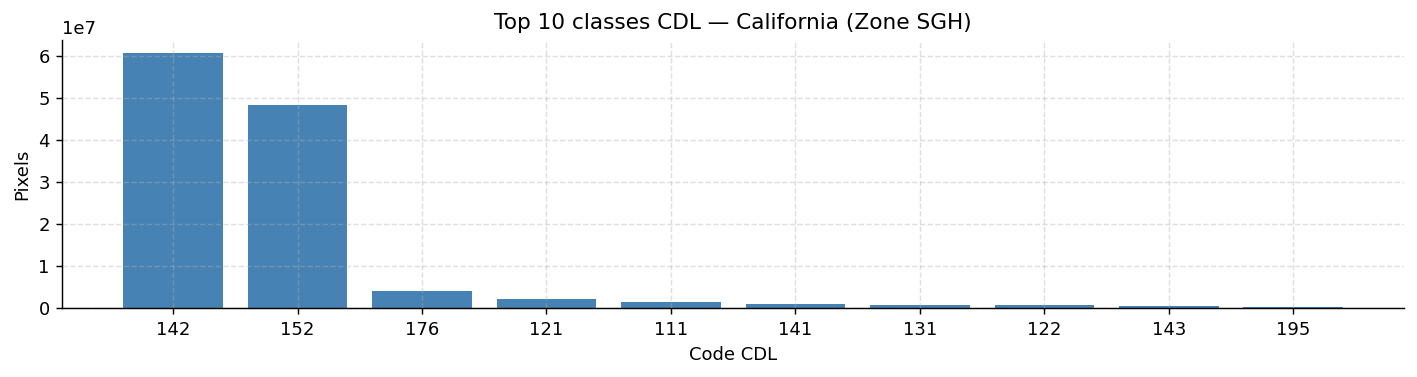

=== Arkansas (Zone SXU) ===
  CRS: EPSG:32615  |  Taille: 10980×10980 px
  Classes agricoles: 43  |  Pixels: 119,683,812


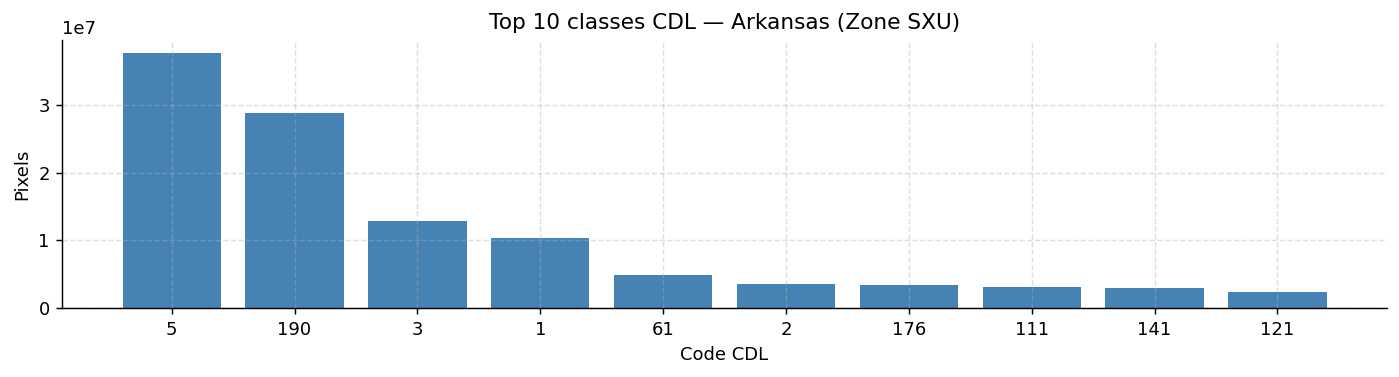

✅ Inspection CDL terminée


In [4]:
def inspect_cdl(cdl_path, title):
    with rasterio.open(cdl_path) as dst:
        print(f'=== {title} ===')
        print(f'  CRS: {dst.crs}  |  Taille: {dst.width}×{dst.height} px')
        data = dst.read(1)
    uniq, cnt = np.unique(data[data > 0], return_counts=True)
    print(f'  Classes agricoles: {len(uniq)}  |  Pixels: {cnt.sum():,}')
    fig, ax = plt.subplots(figsize=(11, 3))
    top10 = sorted(zip(cnt, uniq), reverse=True)[:10]
    tc, tk = zip(*top10)
    ax.bar([str(int(c)) for c in tk], tc, color='steelblue')
    ax.set_title(f'Top 10 classes CDL — {title}')
    ax.set_xlabel('Code CDL'); ax.set_ylabel('Pixels')
    plt.tight_layout(); plt.show()

inspect_cdl(CDL_ALIGNED_CA['SGH'], 'California (Zone SGH)')
if zone_profiles_AR['SXU']['ok']:
    inspect_cdl(CDL_ALIGNED_AR['SXU'], 'Arkansas (Zone SXU)')
print('✅ Inspection CDL terminée')


---
# ÉTAPE 2 — Échantillonnage 10 000 pixels (Table 2)
### ✅ FIX : `Nb of Samples` = total sélectionné (train+val+test), pas les pixels disponibles

In [5]:
def build_code_to_class(classes_dict):
    """Construit le mapping code CDL → nom de classe."""
    mapping = {}
    for name, codes in classes_dict.items():
        for c in codes:
            mapping[c] = name
    return mapping

CODE_TO_CLASS_CA = build_code_to_class(CA_CLASSES)
CODE_TO_CLASS_AR = build_code_to_class(AR_CLASSES)

print('Classes California :', list(CA_CLASSES.keys()) + ['Others'])
print('Classes Arkansas   :', list(AR_CLASSES.keys()) + ['Others'])


Classes California : ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
Classes Arkansas   : ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']


In [6]:
def build_class_data(cdl_aligned_dict, zone_profiles, code_to_class, order,
                        n_target=TOTAL_SAMPLES * 3, chunk_rows=1024, rng_seed=RANDOM_STATE):
    """
    Lecture CDL par blocs + réservoir vectorisé 100% numpy.
    Mémoire max : chunk_rows × width × 1 octet. Pas de boucle Python par pixel.
    """
    rng = np.random.default_rng(rng_seed)
    zone_data = {}

    # Réservoirs pré-alloués taille fixe
    res_rows  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_cols  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_zones = {cls: np.empty(n_target, object)    for cls in order}
    res_fill  = {cls: 0 for cls in order}  # pixels dans le réservoir
    res_seen  = {cls: 0 for cls in order}  # pixels vus au total

    for zone, info in zone_profiles.items():
        if not info['ok']:
            print(f'  Zone {zone}: ⚠️ non disponible'); continue

        with rasterio.open(cdl_aligned_dict[zone]) as src:
            H, W = src.height, src.width
            zone_data[zone] = {'shape': (H, W)}
            zone_seen = 0  # pixels agricoles vus dans cette zone

            for row_off in range(0, H, chunk_rows):
                win   = rasterio.windows.Window(0, row_off, W, min(chunk_rows, H - row_off))
                chunk = src.read(1, window=win)
                ag    = chunk > 0
                if not ag.any(): continue

                rl, cl = np.where(ag)
                rg     = (rl + row_off).astype(np.int32)
                codes  = chunk[rl, cl].astype(np.int32)
                cl     = cl.astype(np.int32)

                for code in np.unique(codes):
                    cls   = code_to_class.get(int(code), 'Others')
                    sel   = codes == code
                    rc    = rg[sel]; cc = cl[sel]
                    n_new = len(rc)
                    fill  = res_fill[cls]
                    seen  = res_seen[cls]

                    if fill < n_target:
                        # --- Phase remplissage direct ---
                        room = n_target - fill
                        take = min(n_new, room)
                        res_rows[cls][fill:fill+take]  = rc[:take]
                        res_cols[cls][fill:fill+take]  = cc[:take]
                        res_zones[cls][fill:fill+take] = zone
                        res_fill[cls] += take
                        res_seen[cls] += take
                        if take == n_new: continue
                        # reste à traiter en mode réservoir
                        rc = rc[take:]; cc = cc[take:]
                        n_new -= take
                        seen  = res_seen[cls]

                    # --- Phase réservoir vectorisée ---
                    # Pour chaque pixel i (0..n_new-1), tire j ~ U[0, seen+i]
                    # Remplace position j si j < n_target
                    i_idx = np.arange(n_new, dtype=np.int64)
                    j     = (rng.random(n_new) * (seen + i_idx + 1)).astype(np.int64)
                    keep  = j < n_target
                    if keep.any():
                        pos = j[keep].astype(np.int32)
                        res_rows[cls][pos]  = rc[keep]
                        res_cols[cls][pos]  = cc[keep]
                        res_zones[cls][pos] = zone
                    res_seen[cls] += n_new
                    zone_seen += n_new

        print(f'  Zone {zone}: {H}×{W} ✅  ({zone_seen:,} px agricoles vus)')

    class_data = {}
    for cls in order:
        n = res_fill[cls]
        class_data[cls] = {
            'rows':  res_rows[cls][:n],
            'cols':  res_cols[cls][:n],
            'zones': res_zones[cls][:n],
        }
    return class_data, zone_data

print('=== Extraction pixels — California ===')
class_data_CA, zone_data_CA = build_class_data(CDL_ALIGNED_CA, zone_profiles_CA, CODE_TO_CLASS_CA, CA_ORDER)
print('\nPixels disponibles par classe [CA]:')
for cls in CA_ORDER:
    n = len(class_data_CA[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')

print('\n=== Extraction pixels — Arkansas ===')
class_data_AR, zone_data_AR = build_class_data(CDL_ALIGNED_AR, zone_profiles_AR, CODE_TO_CLASS_AR, AR_ORDER)
print('\nPixels disponibles par classe [AR]:')
for cls in AR_ORDER:
    n = len(class_data_AR[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')


=== Extraction pixels — California ===
  Zone SFG: 10980×10980 ✅  (120,383,728 px agricoles vus)
  Zone SFH: 10980×10980 ✅  (120,557,072 px agricoles vus)
  Zone SFJ: 10980×10980 ✅  (120,560,400 px agricoles vus)
  Zone SGH: 10980×10980 ✅  (120,560,400 px agricoles vus)

Pixels disponibles par classe [CA]:
  ✅  Grapes      :       30,000 px
  ✅  Rice        :       30,000 px
  ✅  Alfalfa     :       30,000 px
  ✅  Almonds     :       30,000 px
  ✅  Pistachios  :       30,000 px
  ✅  Others      :       30,000 px

=== Extraction pixels — Arkansas ===
  Zone SXU: 10980×10980 ✅  (119,533,812 px agricoles vus)

Pixels disponibles par classe [AR]:
  ✅  Rice        :       30,000 px
  ✅  Soybeans    :       30,000 px
  ✅  Cotton      :       30,000 px
  ✅  Corn        :       30,000 px
  ✅  Others      :       30,000 px


In [7]:
def sample_pixels(class_data, order, n_classes, rng_seed=RANDOM_STATE):
    """Échantillonne exactement TOTAL_SAMPLES pixels avec split train/val/test."""
    rng = np.random.default_rng(rng_seed)
    N_MIN = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1
    test_budget = TOTAL_SAMPLES - n_classes * (N_TRAIN_PER_CLASS + N_VAL_PER_CLASS)
    cuts = np.sort(rng.choice(test_budget - n_classes + 1, n_classes - 1, replace=False))
    cuts = np.concatenate([[0], cuts + np.arange(1, n_classes), [test_budget]])
    test_sizes = np.diff(cuts).astype(int)

    all_rows, all_cols, all_zones, all_labels, all_splits = [], [], [], [], []
    table_rows = []
    total_count = 0

    for k, cls in enumerate(order):
        d = class_data[cls]
        n_avail = len(d['rows'])
        n_test  = min(int(test_sizes[k]), n_avail - N_TRAIN_PER_CLASS - N_VAL_PER_CLASS)
        if n_avail < N_MIN:
            print(f'  ⚠️  {cls} ignorée ({n_avail} px < {N_MIN} minimum)')
            continue
        idx    = rng.permutation(n_avail)
        tr_idx = idx[:N_TRAIN_PER_CLASS]
        v_idx  = idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        te_idx = idx[N_TRAIN_PER_CLASS + N_VAL_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test]
        for sidx, split_name in [(tr_idx,'train'),(v_idx,'val'),(te_idx,'test')]:
            n = len(sidx)
            all_rows.append(d['rows'][sidx]); all_cols.append(d['cols'][sidx])
            all_zones.append(d['zones'][sidx]); all_labels.append(np.full(n, cls))
            all_splits.append(np.full(n, split_name))
        class_total = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test
        total_count += class_total
        table_rows.append({'Class Name': cls, 'Nb of Samples': class_total,
                           'Training': N_TRAIN_PER_CLASS, 'Validation': N_VAL_PER_CLASS,
                           'Testing': n_test})

    df_rec = pd.DataFrame({
        'row': np.concatenate(all_rows), 'col': np.concatenate(all_cols),
        'zone': np.concatenate(all_zones), 'label': np.concatenate(all_labels),
        'split': np.concatenate(all_splits),
    })
    return df_rec, table_rows, total_count

print('=== Échantillonnage California ===')
df_records_CA, table_rows_CA, total_CA = sample_pixels(class_data_CA, CA_ORDER, N_CLASSES_CA)
print(f'✅ CA Total : {total_CA:,} px  | Train:{(df_records_CA["split"]=="train").sum()} Val:{(df_records_CA["split"]=="val").sum()} Test:{(df_records_CA["split"]=="test").sum()}')

print('\n=== Échantillonnage Arkansas ===')
df_records_AR, table_rows_AR, total_AR = sample_pixels(class_data_AR, AR_ORDER, N_CLASSES_AR, rng_seed=RANDOM_STATE+1)
print(f'✅ AR Total : {total_AR:,} px  | Train:{(df_records_AR["split"]=="train").sum()} Val:{(df_records_AR["split"]=="val").sum()} Test:{(df_records_AR["split"]=="test").sum()}')


=== Échantillonnage California ===
✅ CA Total : 10,000 px  | Train:1440 Val:360 Test:8200

=== Échantillonnage Arkansas ===
✅ AR Total : 10,000 px  | Train:1200 Val:300 Test:8500


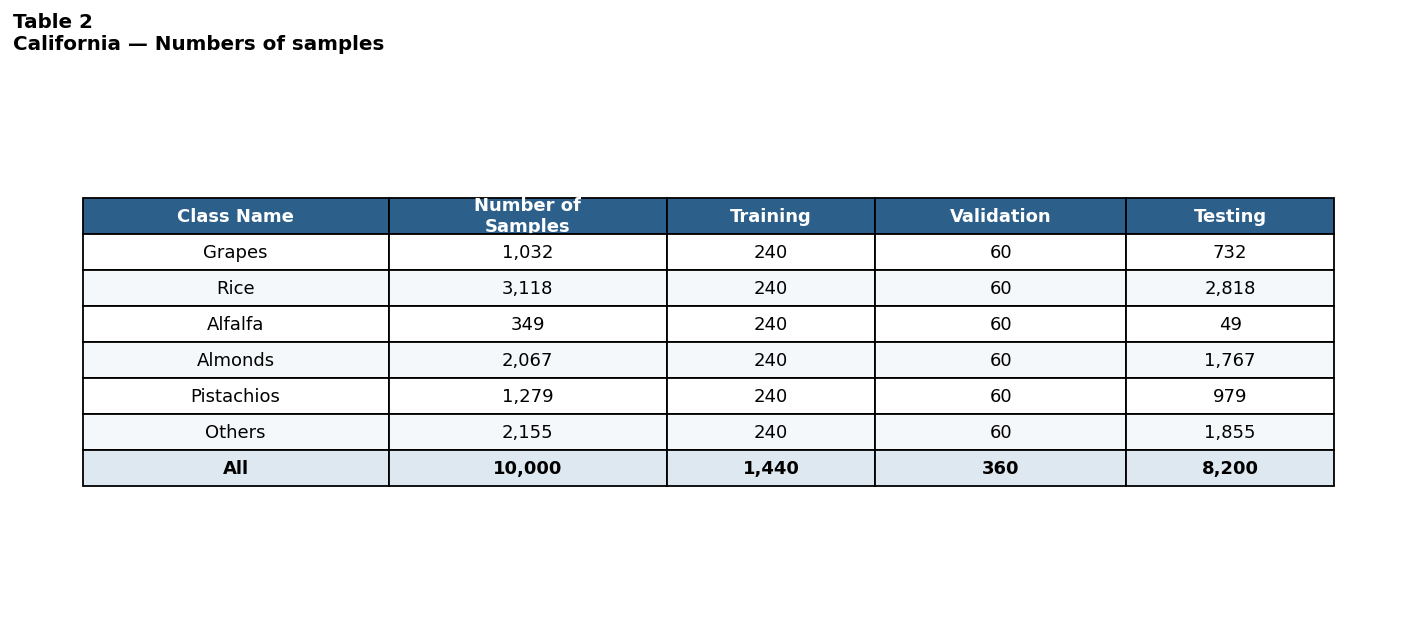

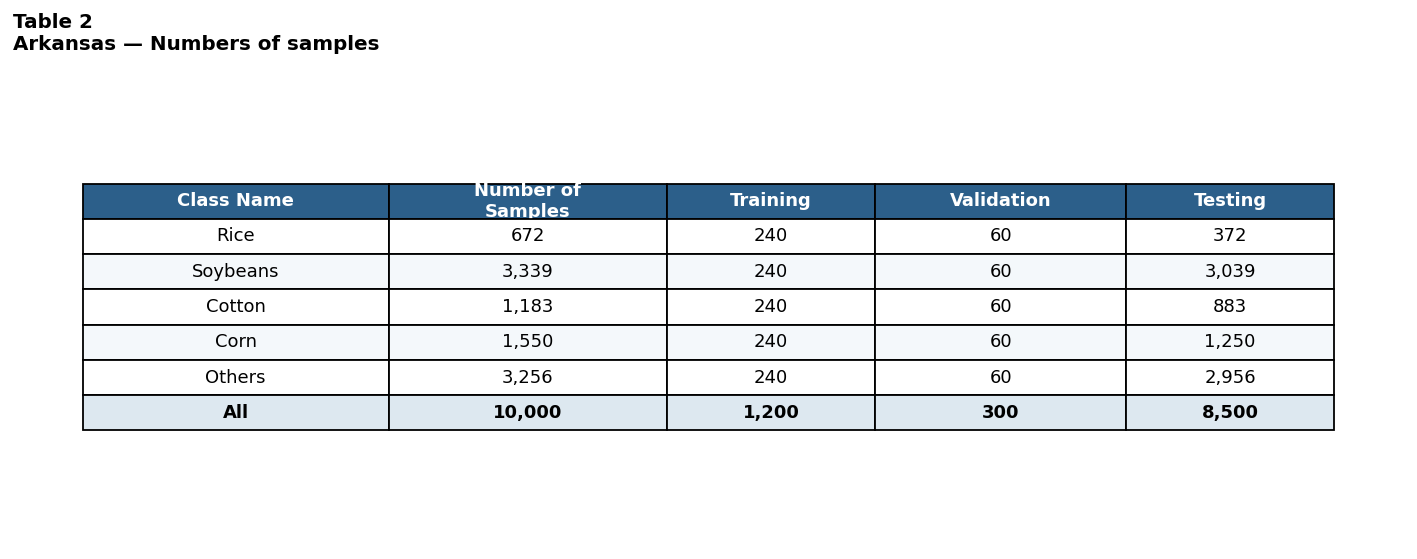

In [8]:
def display_table2(table_rows, title):
    df_t = pd.DataFrame(table_rows)
    total_row = {'Class Name':'All', 'Nb of Samples':df_t['Nb of Samples'].sum(),
                 'Training':df_t['Training'].sum(), 'Validation':df_t['Validation'].sum(),
                 'Testing':df_t['Testing'].sum()}
    df_d = pd.concat([df_t, pd.DataFrame([total_row])], ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 0.55*(len(df_d)+2)))
    ax.axis('off')
    col_labels = ['Class Name','Number of\nSamples','Training','Validation','Testing']
    col_widths = [0.22, 0.20, 0.15, 0.18, 0.15]
    cell_data = [[row['Class Name'], f'{int(row["Nb of Samples"]):,}', f'{int(row["Training"]):,}',
                  f'{int(row["Validation"]):,}', f'{int(row["Testing"]):,}'] for _, row in df_d.iterrows()]
    tbl = ax.table(cellText=cell_data, colLabels=col_labels, colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
    for j in range(len(col_labels)):
        tbl[0,j].set_facecolor('#2c5f8a'); tbl[0,j].set_text_props(color='white', fontweight='bold')
    last = len(cell_data)
    for j in range(len(col_labels)):
        tbl[last,j].set_facecolor('#dde8f0'); tbl[last,j].set_text_props(fontweight='bold')
    for i in range(1, last):
        c = '#f4f8fb' if i%2==0 else 'white'
        for j in range(len(col_labels)): tbl[i,j].set_facecolor(c)
    ax.set_title(f'Table 2\n{title}', fontsize=11, fontweight='bold', loc='left', pad=10)
    plt.tight_layout(); plt.show()

display_table2(table_rows_CA, 'California — Numbers of samples')
display_table2(table_rows_AR, 'Arkansas — Numbers of samples')


---
# ÉTAPE 2b — Extraction spectrale
### 🔧 Fonction get_band_path

In [9]:
def get_band_path(safe_dir_name, granule_dir, file_prefix, band, res):
    dir_path = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / f'R{res}m'
    return dir_path / f'{file_prefix}_{band}_{res}m.jp2'

print('Vérification bandes B04 — California :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_CA.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_CA.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')

print('\nVérification bandes B04 — Arkansas :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_AR.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_AR.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')


Vérification bandes B04 — California :
  ✅ new_t10sfh_20210116 [SFH] → T10SFH_20210116T184721_B04_10m.jp2
  ✅ jan_sgh      [SGH] → T10SGH_20210126T184641_B04_10m.jp2
  ✅ jan_sfg      [SFG] → T10SFG_20210126T184641_B04_10m.jp2
  ✅ new_t10sfg_20210327 [SFG] → T10SFG_20210327T184001_B04_10m.jp2
  ✅ apr_sfg      [SFG] → T10SFG_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210419 [SGH] → T10SGH_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210504 [SGH] → T10SGH_20210504T184919_B04_10m.jp2
  ✅ new_t10sfh_20210511 [SFH] → T10SFH_20210511T183919_B04_10m.jp2
  ✅ july_sgh     [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ july_sfg     [SFG] → T10SFG_20210723T184919_B04_10m.jp2
  ✅ july_sfj     [SFJ] → T10SFJ_20210723T184919_B04_10m.jp2
  ✅ july_sfh     [SFH] → T10SFH_20210723T184919_B04_10m.jp2
  ✅ new_t10sgh_20210809 [SGH] → T10SGH_20210809T183919_B04_10m.jp2
  ✅ new_t10sfj_20210814 [SFJ] → T10SFJ_20210814T183921_B04_10m.jp2
  ✅ new_t10sfh_20210911 [SFH] → T10SFH_20210911T184929_B04_10m.jp2
  ✅ n

In [10]:
def extract_spectral(df_records, dates_map, zone_profiles, zone_data, label):
    """
    Extrait les 10 bandes × N_DATES pour chaque pixel.
    Retourne feat_matrix (numpy) et feat_names (list).
    """
    print(f'\n{"="*60}')
    print(f'  Extraction spectrale — {label}')
    print(f'{"="*60}')

    all_zones = sorted(set(v[3] for v in dates_map.values()))
    zone_masks = {z: (df_records['zone'] == z).values for z in all_zones}
    zone_rows  = {z: df_records['row'].values[zone_masks[z]] for z in all_zones}
    zone_cols  = {z: df_records['col'].values[zone_masks[z]] for z in all_zones}

    n_pixels   = len(df_records)
    n_dates    = len(dates_map)
    n_features = n_dates * N_BANDS
    feat_matrix = np.full((n_pixels, n_features), np.nan, dtype=np.float32)
    feat_names  = []
    col_idx = 0

    for date_name, (safe_dir_name, granule_dir, file_prefix, zone) in dates_map.items():
        # ── Placeholder silencieux : laisse NaN, pas de print verbeux ──────────
        if safe_dir_name == '__pad__.SAFE':
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}')
                col_idx += 1
            continue

        print(f'\n📅 {date_name.upper()} [{zone}]')
        if not zone_profiles.get(zone, {}).get('ok', False):
            print(f'  ⚠️ Zone {zone} non alignée — NaN')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        zmask  = zone_masks[zone]
        rows_z = zone_rows[zone]
        cols_z = zone_cols[zone]
        shape_z = zone_data[zone]['shape']

        if zmask.sum() == 0:
            print('  ⚠️ Aucun pixel — skip')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        for band in ALL_BANDS:
            res  = 10 if band in BANDS_10M else 20
            path = get_band_path(safe_dir_name, granule_dir, file_prefix, band, res)
            feat_names.append(f'{band}_{date_name}')
            if not path.exists():
                print(f'  ❌ {band}', end=' | '); col_idx += 1; continue
            with rasterio.open(path) as src:
                data = src.read(1, out_shape=shape_z, resampling=Resampling.bilinear)
                feat_matrix[zmask, col_idx] = data[rows_z, cols_z].astype(np.float32)
            print(f'  ✅ {band}', end=' | ')
            col_idx += 1
        print()

    n_real = sum(1 for v in dates_map.values() if v[0] != '__pad__.SAFE')
    n_pad  = len(dates_map) - n_real
    nan_pct = 100 * np.isnan(feat_matrix).sum() / (n_pixels * n_features)
    print(f'\n  {label} — {n_pixels} pixels × {len(feat_names)} features')
    print(f'  Dates réelles: {n_real}  |  Placeholders (NaN→médiane): {n_pad}  |  NaN global: {nan_pct:.1f}%')
    return feat_matrix, feat_names

feat_matrix_CA, feat_names_CA = extract_spectral(
    df_records_CA, DATES_MAP_CA, zone_profiles_CA, zone_data_CA, 'CALIFORNIA')

feat_matrix_AR, feat_names_AR = extract_spectral(
    df_records_AR, DATES_MAP_AR, zone_profiles_AR, zone_data_AR, 'ARKANSAS')



  Extraction spectrale — CALIFORNIA

📅 NEW_T10SFH_20210116 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SGH [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFG_20210327 [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 APR_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SGH_20210419 [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SGH_20210504 [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFH_20210511 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 | 

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 🗓️  INTERPOLATION TEMPORELLE LINÉAIRE — 36 dates régulières sur 2021
# Adaptatif : fonctionne avec N dates réelles (N >= 2), quelle que soit
# la quantité d'images téléchargées.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
from datetime import date

START_DOY    = 1
END_DOY      = 360
TARGET_DOYS  = np.linspace(START_DOY, END_DOY, 36).astype(int)
TARGET_NAMES = [f'T{i+1:02d}_doy{d}' for i, d in enumerate(TARGET_DOYS)]
print(f'36 dates cibles (DOY) : {list(TARGET_DOYS)}')
print(f'Espacement moyen : ~{np.diff(TARGET_DOYS).mean():.1f} jours')

def safe_doy(safe_dir, granule_dir, file_prefix):
    if safe_dir == '__pad__.SAFE':
        return None
    try:
        date_str = file_prefix.split('_')[1][:8]
        d = date(int(date_str[:4]), int(date_str[4:6]), int(date_str[6:8]))
        return d.timetuple().tm_yday
    except Exception:
        return None

def build_doy_map(dates_map):
    doy_map = {}
    for name, (safe_dir, granule_dir, file_prefix, zone) in dates_map.items():
        doy = safe_doy(safe_dir, granule_dir, file_prefix)
        if doy is not None:
            doy_map[name] = doy
    return doy_map

doy_map_CA = build_doy_map(DATES_MAP_CA)
doy_map_AR = build_doy_map(DATES_MAP_AR)
print(f'\nCA — DOY des acquisitions réelles ({len(doy_map_CA)}) : {doy_map_CA}')
print(f'AR — DOY des acquisitions réelles ({len(doy_map_AR)}) : {doy_map_AR}')

def interpolate_temporal(feat_matrix_raw, feat_names_raw, dates_map, doy_map, label):
    """
    Interpolation linéaire vectorisée entre les dates réelles.
    - Bords : répétition de la première / dernière valeur connue (np.interp)
    - Fonctionne avec n'importe quel nombre de dates réelles (>= 1)
    - Vectorisé par bande pour éviter la boucle pixel-par-pixel
    """
    n_pixels   = feat_matrix_raw.shape[0]
    n_target   = len(TARGET_DOYS)
    feat_matrix_interp = np.zeros((n_pixels, n_target * N_BANDS), dtype=np.float32)
    feat_names_interp  = [f'{b}_{name}' for name in TARGET_NAMES for b in ALL_BANDS]

    real_date_names = list(doy_map.keys())
    real_doys       = np.array([doy_map[d] for d in real_date_names], dtype=float)

    n_real = len(real_date_names)
    print(f'\n  [{label}] Interpolation — {n_real} dates réelles → 36 cibles')

    if n_real == 0:
        print(f'  ⚠️  [{label}] Aucune date réelle — features mises à 0')
        return feat_matrix_interp, feat_names_interp

    for b_idx, band in enumerate(ALL_BANDS):
        # Récupérer les colonnes brutes pour cette bande
        raw_cols = []
        for d_name in real_date_names:
            col_name = f'{band}_{d_name}'
            raw_cols.append(feat_names_raw.index(col_name) if col_name in feat_names_raw else None)

        # Matrice (n_pixels, n_real) pour cette bande
        band_real = np.full((n_pixels, n_real), np.nan, dtype=np.float32)
        for j, ci in enumerate(raw_cols):
            if ci is not None:
                band_real[:, j] = feat_matrix_raw[:, ci]

        if n_real == 1:
            # Cas dégénéré : on répète la seule valeur sur toutes les cibles
            for t_idx in range(n_target):
                out_col = t_idx * N_BANDS + b_idx
                feat_matrix_interp[:, out_col] = np.where(
                    np.isnan(band_real[:, 0]), 0.0, band_real[:, 0])
        else:
            # Interpolation vectorisée : traite tous les pixels en batch
            # Pour chaque cible, on calcule les poids d'interpolation
            for t_idx, t_doy in enumerate(TARGET_DOYS):
                out_col = t_idx * N_BANDS + b_idx
                # np.interp ne supporte pas les matrices → on utilise une
                # approche vectorisée manuelle qui évite la boucle pixel
                # en traitant les pixels sans NaN en batch
                vals = band_real  # (n_pixels, n_real)

                # Pixels avec toutes valeurs valides (cas majoritaire)
                all_valid = ~np.any(np.isnan(vals), axis=1)  # (n_pixels,)

                if all_valid.any():
                    # Vectorisé : np.interp appliqué sur les pixels valides
                    result = np.array([
                        np.interp(t_doy, real_doys, vals[px])
                        for px in np.where(all_valid)[0]
                    ], dtype=np.float32)
                    feat_matrix_interp[all_valid, out_col] = result

                # Pixels avec quelques NaN (minorité)
                has_nan = ~all_valid
                for px in np.where(has_nan)[0]:
                    v = vals[px]
                    valid = ~np.isnan(v)
                    if valid.sum() == 0:
                        feat_matrix_interp[px, out_col] = 0.0
                    elif valid.sum() == 1:
                        feat_matrix_interp[px, out_col] = v[valid][0]
                    else:
                        feat_matrix_interp[px, out_col] = np.interp(
                            t_doy, real_doys[valid], v[valid])

        print(f'    ✅ {band}', end='  ')
    print()

    nan_pct     = 100 * np.isnan(feat_matrix_interp).sum() / feat_matrix_interp.size
    nonzero_pct = 100 * (feat_matrix_interp != 0).mean()
    print(f'  [{label}] Résultat : {n_pixels} px × {feat_matrix_interp.shape[1]} features')
    print(f'            NaN : {nan_pct:.1f}%  |  Non-nuls : {nonzero_pct:.1f}%  ✅')
    return feat_matrix_interp, feat_names_interp

feat_matrix_CA_interp, feat_names_CA_interp = interpolate_temporal(
    feat_matrix_CA, feat_names_CA, DATES_MAP_CA, doy_map_CA, 'CALIFORNIA')

feat_matrix_AR_interp, feat_names_AR_interp = interpolate_temporal(
    feat_matrix_AR, feat_names_AR, DATES_MAP_AR, doy_map_AR, 'ARKANSAS')

print('\n✅ Interpolation temporelle terminée pour CA et AR')


36 dates cibles (DOY) : [np.int64(1), np.int64(11), np.int64(21), np.int64(31), np.int64(42), np.int64(52), np.int64(62), np.int64(72), np.int64(83), np.int64(93), np.int64(103), np.int64(113), np.int64(124), np.int64(134), np.int64(144), np.int64(154), np.int64(165), np.int64(175), np.int64(185), np.int64(195), np.int64(206), np.int64(216), np.int64(226), np.int64(236), np.int64(247), np.int64(257), np.int64(267), np.int64(277), np.int64(288), np.int64(298), np.int64(308), np.int64(318), np.int64(329), np.int64(339), np.int64(349), np.int64(360)]
Espacement moyen : ~10.3 jours

CA — DOY des acquisitions réelles (21) : {'new_t10sfh_20210116': 16, 'jan_sgh': 26, 'jan_sfg': 26, 'new_t10sfg_20210327': 86, 'apr_sfg': 109, 'new_t10sgh_20210419': 109, 'new_t10sgh_20210504': 124, 'new_t10sfh_20210511': 131, 'july_sgh': 201, 'july_sfg': 204, 'july_sfj': 204, 'july_sfh': 204, 'new_t10sgh_20210809': 221, 'new_t10sfj_20210814': 226, 'new_t10sfh_20210911': 254, 'new_t10sfg_20210913': 256, 'sept_sg

In [12]:
def save_csv(feat_matrix, feat_names, df_records, csv_path, label):
    """
    Sauvegarde le CSV avec les 360 features interpolées.
    FIX : crée le dossier si absent + fallback si PermissionError.
    """
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    df_out = pd.DataFrame(feat_matrix, columns=feat_names)
    df_out.insert(0, 'crop_label', df_records['label'].values)
    df_out.insert(1, 'split',      df_records['split'].values)

    # Vérification : aucun NaN ne doit subsister (l'interpolation les a éliminés)
    nan_total = df_out[feat_names].isnull().sum().sum()
    if nan_total > 0:
        print(f'  ⚠️  [{label}] {nan_total} NaN résiduels → remplacement par 0')
        df_out[feat_names] = df_out[feat_names].fillna(0)

    nonzero_pct = 100 * (df_out[feat_names] != 0).values.mean()

    def _write(path):
        df_out.to_csv(path, index=False)
        size_mb = Path(path).stat().st_size / 1e6
        print(f'✅ [{label}] CSV sauvegardé : {path}  ({size_mb:.1f} MB)')
        print(f'   {len(df_out):,} pixels × {df_out.shape[1]} colonnes')
        print(f'   Valeurs non-nulles : {nonzero_pct:.1f}%  (attendu ~100% après interpolation)')

    try:
        _write(csv_path)
    except PermissionError:
        fallback = Path.home() / 'Documents' / csv_path.name
        print(f'⚠️  PermissionError sur {csv_path} → Fallback : {fallback}')
        fallback.parent.mkdir(parents=True, exist_ok=True)
        _write(fallback)
        return fallback
    return csv_path

# ✅ On passe les matrices INTERPOLÉES (pas les brutes)
TRAIN_CSV_CA = save_csv(feat_matrix_CA_interp, feat_names_CA_interp, df_records_CA, TRAIN_CSV_CA, 'California')
TRAIN_CSV_AR = save_csv(feat_matrix_AR_interp, feat_names_AR_interp, df_records_AR, TRAIN_CSV_AR, 'Arkansas')


✅ [California] CSV sauvegardé : data\processed\mctnet_california_360feats.csv  (24.6 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 68.6%  (attendu ~100% après interpolation)
✅ [Arkansas] CSV sauvegardé : data\processed\mctnet_arkansas_360feats.csv  (29.8 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 89.4%  (attendu ~100% après interpolation)


---
# ÉTAPE 3 — MCT-Net
### ✅ FIX : split Train/Val/Test depuis la colonne 'split' (pas sklearn random split)

In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Index des bandes pour NDVI
ALL_BANDS   = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
IDX_NIR     = ALL_BANDS.index('B08')   # 3
IDX_RED     = ALL_BANDS.index('B04')   # 2
TARGET_DOYS = [1,11,21,31,42,52,62,72,83,93,103,113,
               124,134,144,154,165,175,185,195,206,216,
               226,236,247,257,267,277,288,298,308,318,
               329,339,349,360]

def load_and_prepare(csv_path, label):
    print(f'\n{"="*60}')
    print(f'  Chargement — {label}')
    print(f'{"="*60}')
    df = pd.read_csv(csv_path)
    print(f'  Lignes: {len(df):,}  |  Colonnes: {df.shape[1]}')
    print(f'  Classes: {df["crop_label"].nunique()}  |  Split: {df["split"].value_counts().to_dict()}')

    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['crop_label'])
    num_classes = len(le.classes_)
    print(f'  Classes: {list(le.classes_)}')

    feat_cols = [c for c in df.columns if c not in ['crop_label', 'split', 'label_encoded']]
    assert len(feat_cols) == 360, f'Attendu 360 features, got {len(feat_cols)}'
    print(f'  Features : {len(feat_cols)} (36 dates x 10 bandes)')

    train_mask = df['split'] == 'train'
    scaler = StandardScaler()
    df.loc[train_mask,  feat_cols] = scaler.fit_transform(df.loc[train_mask,  feat_cols])
    df.loc[~train_mask, feat_cols] = scaler.transform(df.loc[~train_mask, feat_cols])

    def get_split(split_name):
        idx = df['split'] == split_name
        X = df.loc[idx, feat_cols].values.reshape(-1, 36, N_BANDS).astype('float32')
        # Input 2 : masque binaire 1=present 0=manquant
        m = (np.abs(X).sum(axis=-1) > 0).astype('float32')
        y = df.loc[idx, 'label_encoded'].values.astype('int64')
        return X, m, y

    X_train, m_train, y_train = get_split('train')
    X_val,   m_val,   y_val   = get_split('val')
    X_test,  m_test,  y_test  = get_split('test')

    print(f'  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
    print(f'  Masque Input2 — taux present: {m_train.mean():.1%}')

    def make_loader(X, m, y, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(m), torch.from_numpy(y))
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

    return (make_loader(X_train, m_train, y_train, True),
            make_loader(X_val, m_val, y_val),
            X_test, m_test, y_test, num_classes, le, scaler)


train_loader_CA, val_loader_CA, X_test_CA, m_test_CA, y_test_CA, num_classes_CA, le_CA, scaler_CA = \
    load_and_prepare(TRAIN_CSV_CA, 'CALIFORNIA')

train_loader_AR, val_loader_AR, X_test_AR, m_test_AR, y_test_AR, num_classes_AR, le_AR, scaler_AR = \
    load_and_prepare(TRAIN_CSV_AR, 'ARKANSAS')



  Chargement — CALIFORNIA
  Lignes: 10,000  |  Colonnes: 362
  Classes: 6  |  Split: {'test': 8200, 'train': 1440, 'val': 360}
  Classes: ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']
  Features : 360 (36 dates x 10 bandes)
  X_train: (1440, 36, 10)  X_val: (360, 36, 10)  X_test: (8200, 36, 10)
  Masque Input2 — taux present: 100.0%

  Chargement — ARKANSAS
  Lignes: 10,000  |  Colonnes: 362
  Classes: 5  |  Split: {'test': 8500, 'train': 1200, 'val': 300}
  Classes: ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans']
  Features : 360 (36 dates x 10 bandes)
  X_train: (1200, 36, 10)  X_val: (300, 36, 10)  X_test: (8500, 36, 10)
  Masque Input2 — taux present: 100.0%


### Architecture MCTNet — Conforme au paper (Wang et al. 2024)
#### 3 stages CTFusion (CNN parallele Transformer) + ALPE + ~55K params

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# 🏗️  ARCHITECTURE MCTNet — fidèle aux Fig. 3, 5, 6 du paper
# ══════════════════════════════════════════════════════════════════════════════

# ── Fig. 5 : ECA (Efficient Channel Attention) ────────────────────────────────
class ECA(nn.Module):
    """Efficient Channel Attention (Wang et al. 2020).
    Fig. 5 : Average Pooling → Conv1D → sigmoid → element-wise multiply.
    """
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        k = kernel_size | 1                            # assure impair
        self.avg_pool = nn.AdaptiveAvgPool1d(1)        # squeeze temporel
        self.conv     = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):                              # x : (B, T, C)
        # squeeze sur T → (B, C, 1) → transpose → (B, 1, C)
        y = self.avg_pool(x.transpose(1, 2))           # (B, C, 1)
        y = self.conv(y.transpose(1, 2))               # (B, 1, C)
        w = self.sigmoid(y)                            # (B, 1, C) poids par canal
        return x * w                                   # (B, T, C) repondéré


# ── Fig. 5 : ALPE (Attention-based Learnable Positional Encoding) ─────────────
class ALPE(nn.Module):
    """ALPE : PE(t) ⊗ mask → Conv1D → ECA → ajout à x  (Fig. 5).
    L'encodage absolu est modulé par le masque de disponibilité, puis
    affiné par une Conv1D et l'attention canal ECA.
    """
    def __init__(self, n_dates, d_model):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, bias=False)
        self.eca  = ECA(d_model)
        # Encodage sinusoïdal absolu (fixe, non appris)
        pe  = torch.zeros(n_dates, d_model)
        pos = torch.arange(n_dates).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe)                 # (T, d_model)

    def forward(self, x, mask):                        # x:(B,T,d)  mask:(B,T)
        B, T, _ = x.shape
        # 1. PE masqué : zéro aux dates absentes
        pe_masked = self.pe[:T].unsqueeze(0).expand(B, -1, -1) * mask.unsqueeze(-1)
        # 2. Conv1D spectral sur les canaux → (B, d, T) → (B, T, d)
        pe_conv   = self.conv(pe_masked.transpose(1, 2)).transpose(1, 2)
        # 3. ECA : pondération par canal
        pe_eca    = self.eca(pe_conv)                  # (B, T, d)
        # 4. Ajout résiduel à l'entrée
        return x + pe_eca


# ── Fig. 6 : CNN Sub-Module ───────────────────────────────────────────────────
class CNNSubModule(nn.Module):
    """CNN sub-module (Fig. 6) :
    Conv1D → Norm → Conv1D → Norm → ReLU  +  skip connection.

    Le skip (flèche latérale sur la figure) contourne le double bloc
    Conv-Norm et se fusionne AVANT le ReLU final.
    """
    def __init__(self, in_ch, out_ch, ks=3):
        super().__init__()
        p = ks // 2
        # Bloc principal : Conv → BN → Conv → BN  (ReLU séparé après le skip)
        self.conv1 = nn.Conv1d(in_ch,  out_ch, ks, padding=p, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, ks, padding=p, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        # Skip connection : ajuste les canaux si nécessaire
        self.shortcut = (nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False)
                         if in_ch != out_ch else nn.Identity())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):                              # x : (B, C_in, T)
        # Bloc principal
        out = self.conv1(x)                            # (B, C_out, T)
        out = self.bn1(out)
        out = self.conv2(out)                          # (B, C_out, T)
        out = self.bn2(out)
        # Skip + ReLU final (Fig. 6 : flèche latérale + ReLU en haut)
        return self.relu(out + self.shortcut(x))


# ── Fig. 4 : Transformer Sub-Module ──────────────────────────────────────────
class TransformerSubModule(nn.Module):
    """Transformer encoder (Fig. 4) avec positional encoding.
    Stage 1 : ALPE (Fig. 5).  Stages 2-3 : PE sinusoïdal standard.
    """
    def __init__(self, d_model, nhead, n_dates, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.pos = ALPE(n_dates, d_model)
        else:
            # PE sinusoïdal fixe pour les stages sans ALPE
            pe  = torch.zeros(1, n_dates, d_model)
            pos = torch.arange(n_dates).float().unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[0, :, 0::2] = torch.sin(pos * div)
            pe[0, :, 1::2] = torch.cos(pos * div[:d_model // 2])
            self.register_buffer('pe', pe)
        # Projection linéaire d'entrée
        self.proj    = nn.Linear(d_model, d_model)
        # Encoder Transformer : Multi-Head Attention + Add&Norm + FFN + Add&Norm
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4, dropout=0.1,
                batch_first=True, norm_first=False        # Post-LN (standard)
            ), num_layers=1)

    def forward(self, x, mask=None):                   # x : (B, T, d)
        x = self.proj(x)                               # projection linéaire
        if self.use_alpe:
            x = self.pos(x, mask)                      # ALPE (stage 1)
        else:
            x = x + self.pe[:, :x.size(1), :]         # PE sinusoïdal
        return self.encoder(x)                         # (B, T, d)


# ── Fig. 3 : CTFusion Module ──────────────────────────────────────────────────
class CTFusion(nn.Module):
    """CTFusion (Fig. 3) : CNN sub-module ‖ Transformer sub-module → Concat.

    Flux :
      Input1 (spectral)  → CNNSubModule      → out_cnn  (B, d, T)
      Input1 + pos enc   → TransformerSubMod → out_trans (B, T, d)
      Concat(out_cnn.T, out_trans) → (B, T, 2d)

    La projection linéaire aligne les canaux d'entrée avec d_model
    pour la branche Transformer si in_ch ≠ d_model.
    """
    def __init__(self, in_ch, d_model, nhead, n_dates, ks=3, use_alpe=False):
        super().__init__()
        self.cnn   = CNNSubModule(in_ch, d_model, ks)
        # Alignement de dimension pour la branche Transformer
        self.input_proj = (nn.Linear(in_ch, d_model, bias=False)
                           if in_ch != d_model else nn.Identity())
        self.trans = TransformerSubModule(d_model, nhead, n_dates, use_alpe)

    def forward(self, x_cnn, x_trans, mask=None):
        # x_cnn   : (B, C_in, T)   — format Conv1D
        # x_trans : (B, T, C_in)   — format Transformer
        out_cnn   = self.cnn(x_cnn)                    # (B, d, T)
        x_aligned = self.input_proj(x_trans)           # (B, T, d)
        out_trans = self.trans(x_aligned, mask)        # (B, T, d)
        # Concat sur la dimension canal : (B, T, 2d)
        concat    = torch.cat([out_cnn.transpose(1, 2), out_trans], dim=-1)
        return out_cnn, out_trans, concat              # concat → entrée du stage suivant


# ── MCTNet : 3 stages CTFusion + Global Max Pooling + MLP ────────────────────
class MCTNet(nn.Module):
    """MCTNet complet (Fig. 3) : 3 × CTFusion + MaxPool + Global MaxPool + MLP.

    Dimensions (d_model=9, T=36) :
      Stage 1 : in=10  → concat (B, 36, 20)  → MaxPool → (B, 20, 18)
      Stage 2 : in=20  → concat (B, 18, 40)  → MaxPool → (B, 40, 9)
      Stage 3 : in=40  → concat (B,  9, 80)  → GlobMax → (B, 80)
      MLP     : 80 → num_classes  ← confirme "80×1 Intermediate Features" Fig. 3

    Input 1 : (B, T, N_BANDS) — séries spectrales
    Input 2 : (B, T)          — masque binaire de disponibilité
    """
    def __init__(self, n_dates, n_bands, num_classes,
                 nhead=5, ks=3, d_model=10):
        super().__init__()
        t1, t2, t3 = n_dates, n_dates // 2, n_dates // 4

        # Stage 1 : in_ch=n_bands, out d_model; avec ALPE
        self.stage1 = CTFusion(n_bands,     d_model,     nhead, t1, ks, use_alpe=True)
        self.pool1  = nn.MaxPool1d(kernel_size=2, stride=2)

        # Stage 2 : in_ch = 2*d_model (concat stage 1)
        self.stage2 = CTFusion(d_model * 2, d_model * 2, nhead, t2, ks, use_alpe=False)
        self.pool2  = nn.MaxPool1d(kernel_size=2, stride=2)

        # Stage 3 : in_ch = 2*(2*d_model) = 4*d_model (concat stage 2)
        self.stage3 = CTFusion(d_model * 4, d_model * 4, nhead, t3, ks, use_alpe=False)

        # Global Max Pooling → vecteur de taille 2*(4*d_model) = 8*d_model
        self.gpool  = nn.AdaptiveMaxPool1d(1)

        # MLP de classification (Linear unique, papier §3.4)
        self.fc     = nn.Linear(d_model * 8, num_classes)

    def forward(self, x1, x2):
        # x1 : (B, T, N_BANDS)   x2 : (B, T) masque
        # ── Stage 1 ──────────────────────────────────────────────────────────
        _, _, c1 = self.stage1(
            x1.transpose(1, 2),    # (B, N_BANDS, T) pour CNN
            x1,                    # (B, T, N_BANDS) pour Transformer
            mask=x2
        )                          # c1 : (B, T, 2*d)
        p1 = self.pool1(c1.transpose(1, 2))   # (B, 2*d, T//2)

        # ── Stage 2 ──────────────────────────────────────────────────────────
        _, _, c2 = self.stage2(
            p1,                    # (B, 2*d, T//2) pour CNN
            p1.transpose(1, 2)     # (B, T//2, 2*d) pour Transformer
        )                          # c2 : (B, T//2, 4*d)
        p2 = self.pool2(c2.transpose(1, 2))   # (B, 4*d, T//4)

        # ── Stage 3 ──────────────────────────────────────────────────────────
        _, _, c3 = self.stage3(
            p2,                    # (B, 4*d, T//4) pour CNN
            p2.transpose(1, 2)     # (B, T//4, 4*d) pour Transformer
        )                          # c3 : (B, T//4, 8*d)

        # ── Global Max Pooling + MLP ─────────────────────────────────────────
        feat = self.gpool(c3.transpose(1, 2)).squeeze(-1)   # (B, 8*d)
        return self.fc(feat)                                 # (B, num_classes)


def build_model(n_dates, n_bands, num_classes, device):
    model = MCTNet(n_dates=n_dates, n_bands=n_bands, num_classes=num_classes).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    # Vérification forward pass
    with torch.no_grad():
        dummy_x1   = torch.zeros(2, n_dates, n_bands).to(device)
        dummy_mask = torch.ones(2, n_dates).to(device)
        out = model(dummy_x1, dummy_mask)
    print(f'  MCTNet — Dates:{n_dates} Bandes:{n_bands} Classes:{num_classes} '
          f'Params:{total_params:,} (paper ~55K) output:{out.shape}')
    assert out.shape == (2, num_classes), f"Shape inattendu : {out.shape}"
    return model


print('=== Initialisation des modèles MCTNet ====================')
model_CA = build_model(36, N_BANDS, num_classes_CA, DEVICE)
model_AR = build_model(36, N_BANDS, num_classes_AR, DEVICE)
print(f'  Device : {DEVICE}')
print('✅ Architecture MCTNet conforme aux Fig. 3, 5, 6 du paper')

=== Initialisation des modèles MCTNet ====================
  MCTNet — Dates:36 Bandes:10 Classes:6 Params:41,949 (paper ~55K) output:torch.Size([2, 6])
  MCTNet — Dates:36 Bandes:10 Classes:5 Params:41,868 (paper ~55K) output:torch.Size([2, 5])
  Device : cpu
✅ Architecture MCTNet conforme aux Fig. 3, 5, 6 du paper


### 🏋️ Boucle d'entraînement (200 époques) avec validation

In [33]:
def train_model(model, train_loader, val_loader, epochs, lr, device, label):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    history   = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}
    best_val_loss = float('inf')
    best_state    = None

    print(f'\n{"="*60}')
    print(f'  Entrainement MCTNet — {label}')
    print(f'  Device:{device}  Batch:{BATCH_SIZE}  LR:{lr}  Epoques:{epochs}')
    print(f'{"="*60}')

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total, nan_b = 0.0, 0, 0, 0
        for batch_X, batch_mask, batch_y in train_loader:
            batch_X, batch_mask, batch_y = batch_X.to(device), batch_mask.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X, batch_mask)   # Input1 + Input2
            loss    = criterion(outputs, batch_y)
            if torch.isnan(loss) or torch.isinf(loss):
                nan_b += 1; continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0); correct += (predicted == batch_y).sum().item()

        scheduler.step()
        tr_acc  = 100 * correct / total if total > 0 else 0.0
        tr_loss = total_loss / max(len(train_loader) - nan_b, 1)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_mask, batch_y in val_loader:
                batch_X, batch_mask, batch_y = batch_X.to(device), batch_mask.to(device), batch_y.to(device)
                outputs  = model(batch_X, batch_mask)
                v_loss  += criterion(outputs, batch_y).item()
                _, pred  = torch.max(outputs, 1)
                v_total += batch_y.size(0); v_correct += (pred == batch_y).sum().item()

        val_acc  = 100 * v_correct / max(v_total, 1)
        val_loss = v_loss / max(len(val_loader), 1)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        history['loss'].append(tr_loss); history['accuracy'].append(tr_acc)
        history['val_loss'].append(val_loss); history['val_accuracy'].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Epoque [{epoch+1:3d}/{epochs}]  Loss:{tr_loss:.4f}  Acc:{tr_acc:.2f}%'
                  f'  | Val Loss:{val_loss:.4f}  Val Acc:{val_acc:.2f}%')

    if best_state:
        model.load_state_dict(best_state)
        print(f'  Best model restaure (val_loss={best_val_loss:.4f})')
    return history


history_CA = train_model(model_CA, train_loader_CA, val_loader_CA, EPOCHS, LR, DEVICE, 'CALIFORNIA')
history_AR = train_model(model_AR, train_loader_AR, val_loader_AR, EPOCHS, LR, DEVICE, 'ARKANSAS')



  Entrainement MCTNet — CALIFORNIA
  Device:cpu  Batch:32  LR:0.0005  Epoques:200
  Epoque [  1/200]  Loss:1.9271  Acc:18.40%  | Val Loss:1.7561  Val Acc:14.44%
  Epoque [  5/200]  Loss:1.2575  Acc:53.26%  | Val Loss:1.4104  Val Acc:48.06%
  Epoque [ 10/200]  Loss:1.0142  Acc:63.26%  | Val Loss:1.0983  Val Acc:59.72%
  Epoque [ 15/200]  Loss:0.8763  Acc:68.06%  | Val Loss:0.9869  Val Acc:61.67%
  Epoque [ 20/200]  Loss:0.7958  Acc:71.94%  | Val Loss:0.9368  Val Acc:64.72%
  Epoque [ 25/200]  Loss:0.7361  Acc:73.19%  | Val Loss:0.9031  Val Acc:66.94%
  Epoque [ 30/200]  Loss:0.6897  Acc:75.00%  | Val Loss:0.8846  Val Acc:66.94%
  Epoque [ 35/200]  Loss:0.6519  Acc:76.60%  | Val Loss:0.8746  Val Acc:66.94%
  Epoque [ 40/200]  Loss:0.6261  Acc:77.29%  | Val Loss:0.8623  Val Acc:69.44%
  Epoque [ 45/200]  Loss:0.6004  Acc:78.68%  | Val Loss:0.8515  Val Acc:69.44%
  Epoque [ 50/200]  Loss:0.5871  Acc:79.24%  | Val Loss:0.8375  Val Acc:70.28%
  Epoque [ 55/200]  Loss:0.5582  Acc:80.56%  | V

### 📈 Courbes Loss & Accuracy (Train + Validation)

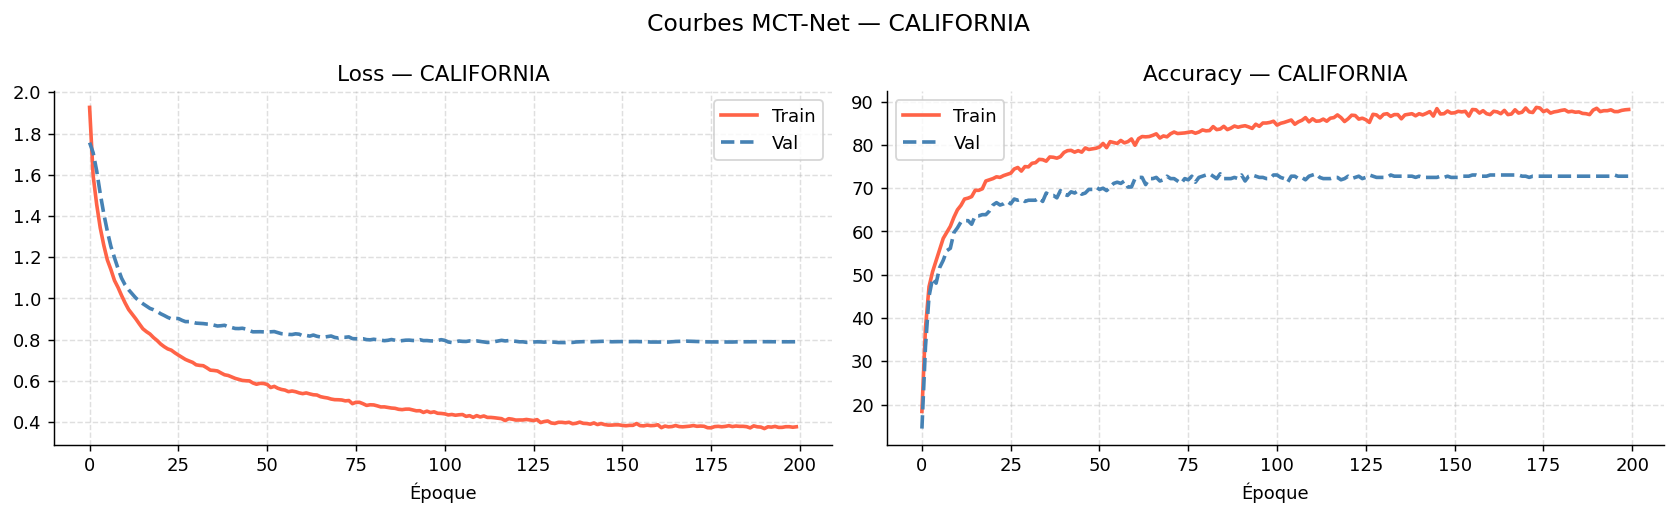

  [CALIFORNIA] Train: Loss=0.3770 Acc=88.19%  |  Val: Loss=0.7896 Acc=72.78%


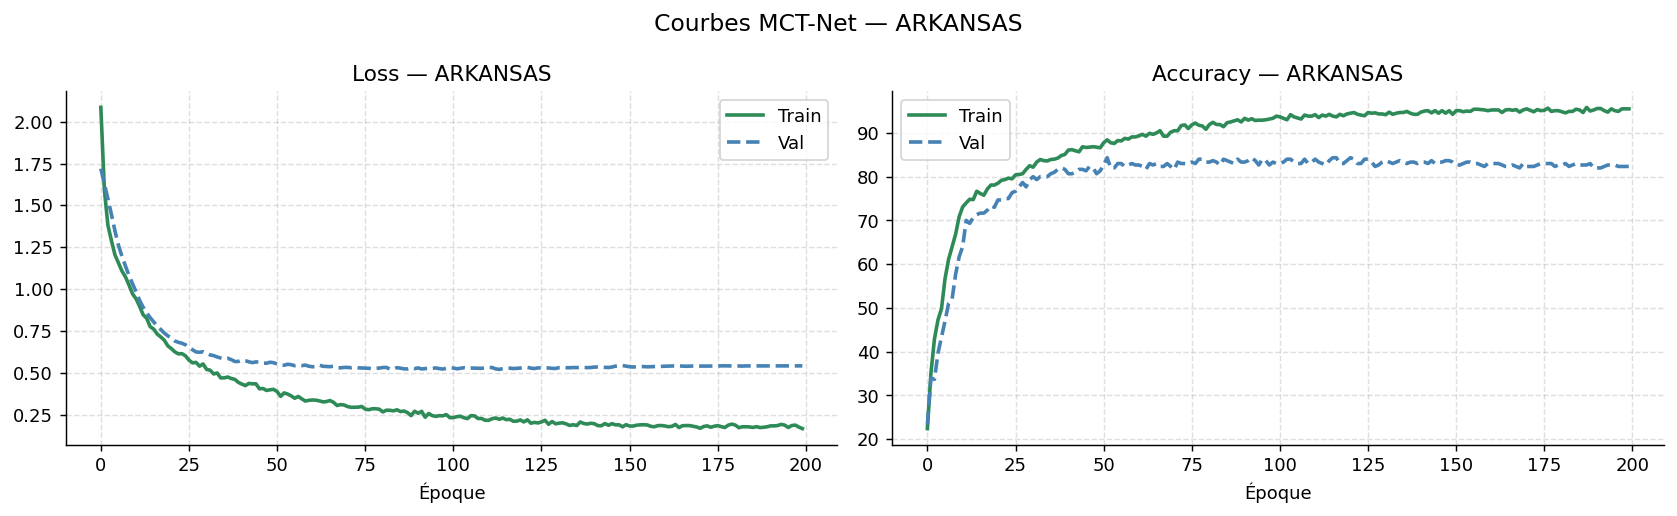

  [ARKANSAS] Train: Loss=0.1661 Acc=95.50%  |  Val: Loss=0.5409 Acc=82.33%


In [34]:
def plot_history(history, label, color='tomato'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['loss'],     color=color,      linewidth=2, label='Train')
    axes[0].plot(history['val_loss'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[0].set_title(f'Loss — {label}'); axes[0].set_xlabel('Époque'); axes[0].legend()
    axes[1].plot(history['accuracy'],     color=color,      linewidth=2, label='Train')
    axes[1].plot(history['val_accuracy'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[1].set_title(f'Accuracy — {label}'); axes[1].set_xlabel('Époque'); axes[1].legend()
    plt.suptitle(f'Courbes MCT-Net — {label}', fontsize=13)
    plt.tight_layout(); plt.show()
    print(f'  [{label}] Train: Loss={history["loss"][-1]:.4f} Acc={history["accuracy"][-1]:.2f}%'
          f'  |  Val: Loss={history["val_loss"][-1]:.4f} Acc={history["val_accuracy"][-1]:.2f}%')

plot_history(history_CA, 'CALIFORNIA', color='tomato')
plot_history(history_AR, 'ARKANSAS',   color='seagreen')


### 🧪 Évaluation sur le jeu de TEST

In [35]:
def evaluate_test(model, X_test, m_test, y_test, le, device, label):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    m_t = torch.tensor(m_test, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_test, dtype=torch.long).to(device)
    with torch.no_grad():
        outputs      = model(X_t, m_t)
        _, predicted = torch.max(outputs, 1)
        acc = 100 * (predicted == y_t).sum().item() / len(y_t)
    pred_np = predicted.cpu().numpy()
    print(f'[{label}] Accuracy TEST : {acc:.2f}%  (classes: {list(le.classes_)})')
    return acc, pred_np


test_acc_CA, pred_CA = evaluate_test(model_CA, X_test_CA, m_test_CA, y_test_CA, le_CA, DEVICE, 'CALIFORNIA')
test_acc_AR, pred_AR = evaluate_test(model_AR, X_test_AR, m_test_AR, y_test_AR, le_AR, DEVICE, 'ARKANSAS')


[CALIFORNIA] Accuracy TEST : 77.50%  (classes: ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice'])
[ARKANSAS] Accuracy TEST : 79.75%  (classes: ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans'])


### Profils NDVI — Fig. 2 du paper

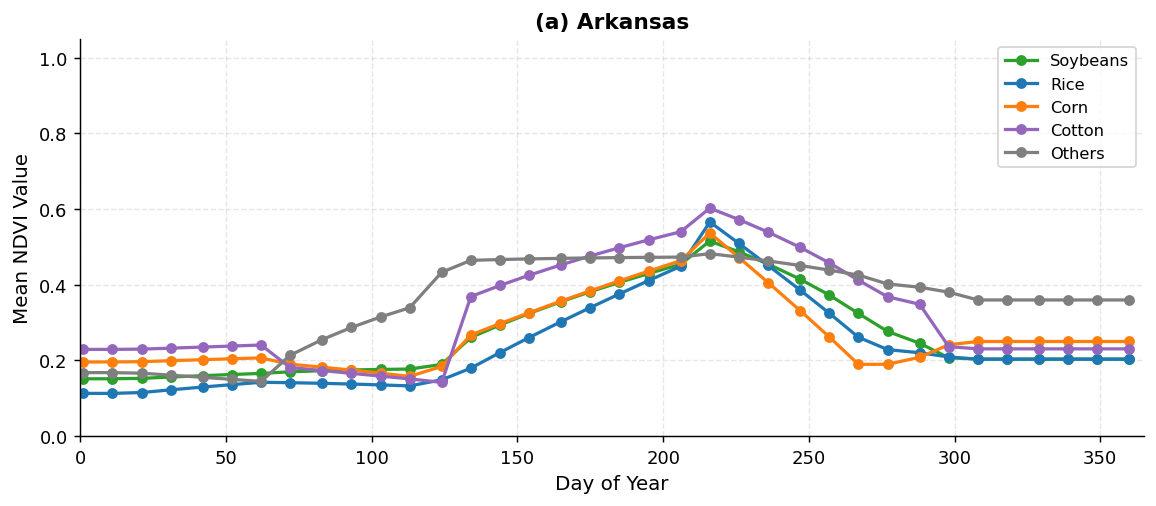

  NDVI Arkansas sauvegarde -> data\processed\ndvi_arkansas.png


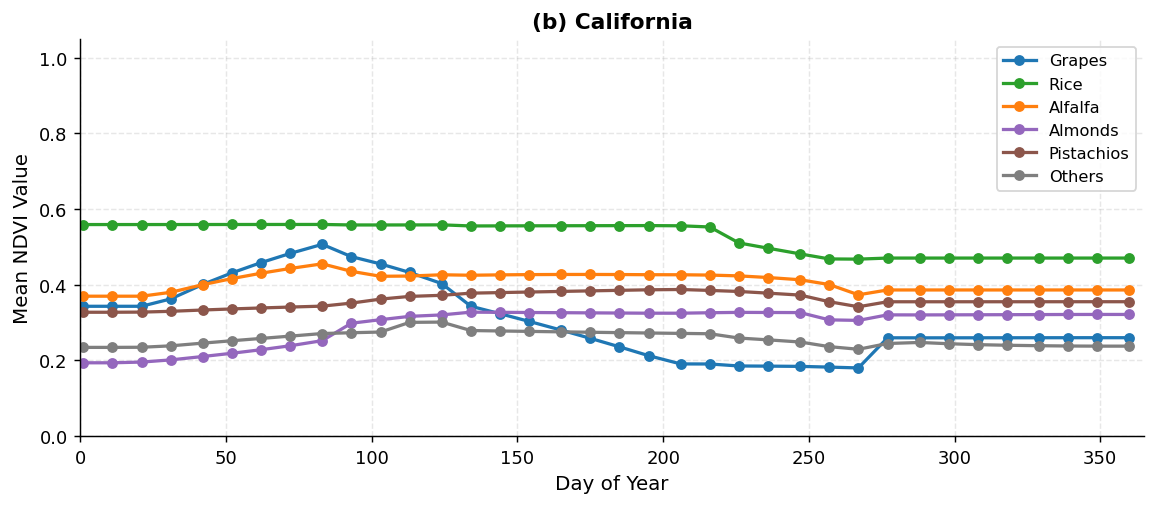

  NDVI California sauvegarde -> data\processed\ndvi_california.png


In [36]:
CA_COLORS = {
    'Grapes':'#1f77b4','Rice':'#2ca02c','Alfalfa':'#ff7f0e',
    'Almonds':'#9467bd','Pistachios':'#8c564b','Others':'#7f7f7f'
}
AR_COLORS = {
    'Soybeans':'#2ca02c','Rice':'#1f77b4','Corn':'#ff7f0e',
    'Cotton':'#9467bd','Others':'#7f7f7f'
}

def plot_ndvi_profiles(csv_path, order, color_map, label, sub='a'):
    """Reproduit la Fig. 2 du paper : profils NDVI moyens par culture."""
    df = pd.read_csv(csv_path)
    feat_cols = [c for c in df.columns if c not in ['crop_label','split']]
    X      = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype(float)
    labels = df['crop_label'].values

    NIR  = X[:, :, IDX_NIR]
    RED  = X[:, :, IDX_RED]
    NDVI = (NIR - RED) / (NIR + RED + 1e-6)
    NDVI[(np.abs(NIR) < 1e-6) & (np.abs(RED) < 1e-6)] = np.nan

    fig, ax = plt.subplots(figsize=(9, 4))
    for cls in order:
        idx = labels == cls
        if idx.sum() == 0:
            continue
        mean_ndvi = np.nanmean(NDVI[idx], axis=0)
        coverage  = (~np.isnan(NDVI[idx])).mean(axis=0)
        valid     = coverage >= 0.1
        doys      = np.array(TARGET_DOYS)
        ax.plot(doys[valid], mean_ndvi[valid],
                marker='o', markersize=5, linewidth=1.8,
                color=color_map.get(cls, 'gray'), label=cls)

    ax.set_xlabel('Day of Year', fontsize=11)
    ax.set_ylabel('Mean NDVI Value', fontsize=11)
    ax.set_title(f'({sub}) {label}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 365)
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    out_path = PROCESSED_DIR / f'ndvi_{label.lower()}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  NDVI {label} sauvegarde -> {out_path}')


plot_ndvi_profiles(TRAIN_CSV_AR, ['Soybeans','Rice','Corn','Cotton','Others'], AR_COLORS, 'Arkansas', 'a')
plot_ndvi_profiles(TRAIN_CSV_CA, CA_ORDER, CA_COLORS, 'California', 'b')


### Matrices de confusion normalisees — Fig. 7 & 8 du paper

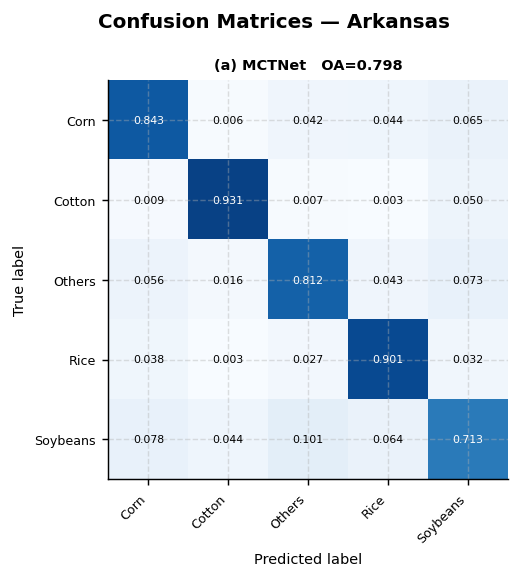

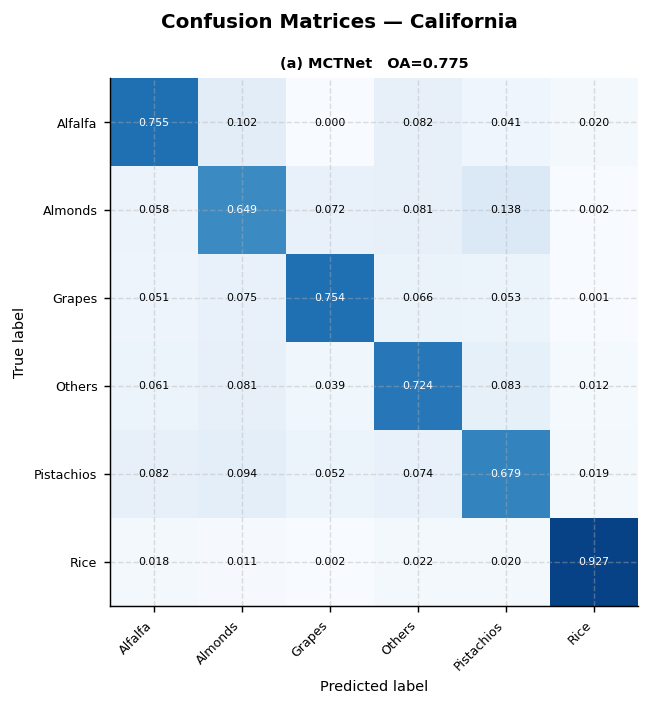

Matrices sauvegardees dans data\processed


In [37]:
def plot_confusion_matrix(y_true, y_pred, classes, title='', ax=None):
    """Matrice de confusion normalisee avec valeurs — style Fig. 7/8 du paper."""
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    n  = len(classes)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels(classes, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(n))
    ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel('Predicted label', fontsize=8)
    ax.set_ylabel('True label', fontsize=8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    for i in range(n):
        for j in range(n):
            color = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.3f}', ha='center', va='center',
                    fontsize=6, color=color)


# Arkansas — Fig. 7
fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
oa_ar = (pred_AR == y_test_AR).mean()
plot_confusion_matrix(y_test_AR, pred_AR, le_AR.classes_,
                      title=f'(a) MCTNet   OA={oa_ar:.3f}', ax=ax)
plt.suptitle('Confusion Matrices — Arkansas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_arkansas.png', dpi=150, bbox_inches='tight')
plt.show()

# California — Fig. 8
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))
oa_ca = (pred_CA == y_test_CA).mean()
plot_confusion_matrix(y_test_CA, pred_CA, le_CA.classes_,
                      title=f'(a) MCTNet   OA={oa_ca:.3f}', ax=ax)
plt.suptitle('Confusion Matrices — California', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_california.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Matrices sauvegardees dans {PROCESSED_DIR}')


### 💾 Sauvegarde du modèle

In [38]:
def save_model(model, path, num_classes, le, history, test_acc, n_dates, label):
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes'     : num_classes,
        'label_classes'   : list(le.classes_),
        'history'         : history,
        'test_accuracy'   : test_acc,
        'n_dates'         : n_dates,
        'n_bands'         : N_BANDS,
    }, path)
    print(f'✅ [{label}] Modèle sauvegardé : {path}')
    print(f'   Accuracy test : {test_acc:.2f}%')

save_model(model_CA, MODEL_PATH_CA, num_classes_CA, le_CA, history_CA, test_acc_CA, len(DATES_MAP_CA), 'CALIFORNIA')
save_model(model_AR, MODEL_PATH_AR, num_classes_AR, le_AR, history_AR, test_acc_AR, len(DATES_MAP_AR), 'ARKANSAS')

print('\n🎉 Pipeline MCT-Net complet — California + Arkansas terminé !')


✅ [CALIFORNIA] Modèle sauvegardé : models\mctnet_california_final.pth
   Accuracy test : 77.50%
✅ [ARKANSAS] Modèle sauvegardé : models\mctnet_arkansas_final.pth
   Accuracy test : 79.75%

🎉 Pipeline MCT-Net complet — California + Arkansas terminé !
